In [26]:

# %matplotlib inline

In [27]:
from preprocess_signal import preprocessing


subject #[[1]]
exercise #[[1]]
0.0     351
5.0      58
3.0      53
1.0      50
8.0      44
6.0      43
12.0     42
4.0      41
10.0     39
2.0      37
7.0      36
9.0      35
11.0     35
Name: count, dtype: int64
0.0     908
3.0      30
1.0      26
10.0     25
12.0     23
5.0      22
4.0      18
6.0      17
7.0      17
9.0      17
2.0      16
8.0      16
11.0     15
Name: count, dtype: int64


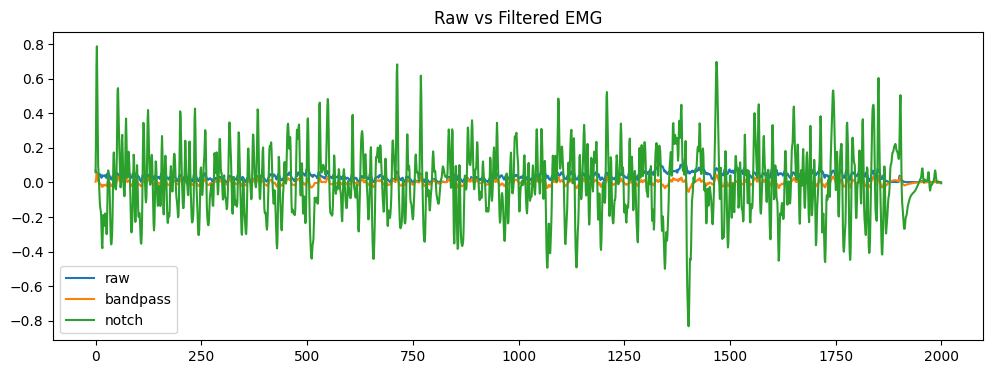

In [28]:
X_train, y_train, X_test, y_test, cw = preprocessing("C:/Users/shubh/CMPM118-Winter2026/NinaProData/s1/S1_A1_E1.mat")

In [29]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np

def plot_emg_spectrogram(signal_data, fs=2000, title="EMG Spectrogram"):
    """
    signal_data: 1D numpy array or pandas Series (one EMG channel)
    fs: sampling rate (Hz)
    """
    f, t, Sxx = spectrogram(signal_data, fs=fs, nperseg=256, noverlap=128)

    plt.figure(figsize=(12, 5))
    plt.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
    plt.colorbar(label='Power (dB)')
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.ylim([0, 500])  # EMG band of interest
    plt.show()

In [30]:
from preprocess_signal import load_data, filter_data, notch_filter, normalise

data = load_data("C:/Users/shubh/CMPM118-Winter2026/NinaProData/s1/S1_A1_E1.mat")
bp = filter_data(data, f=[20,450], btype='bandpass')
notch = notch_filter(bp, f0=60, Q=30)
norm = normalise(notch, train_reps=[1,2,3])

subject #[[1]]
exercise #[[1]]


In [ ]:
plot_emg_spectrogram(notch.iloc[:, 0], title="Notch Filtered EMG Spectrogram")


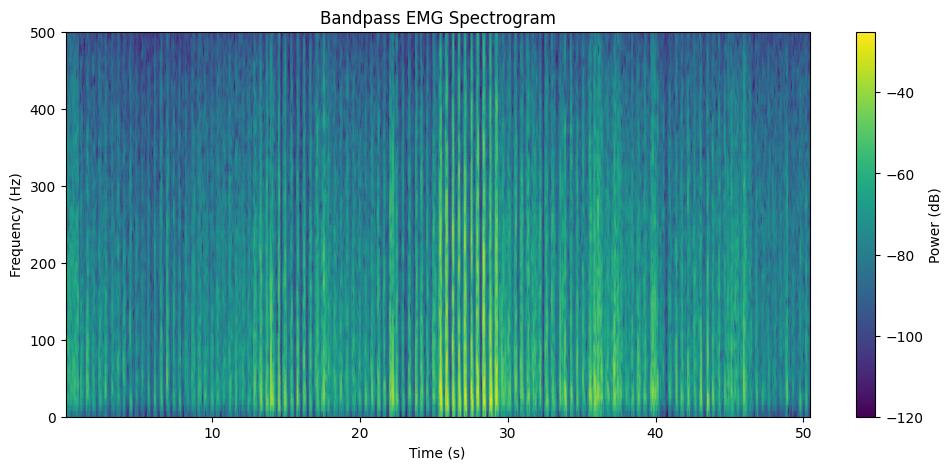

In [31]:
plot_emg_spectrogram(bp.iloc[:, 0], title="Bandpass EMG Spectrogram")

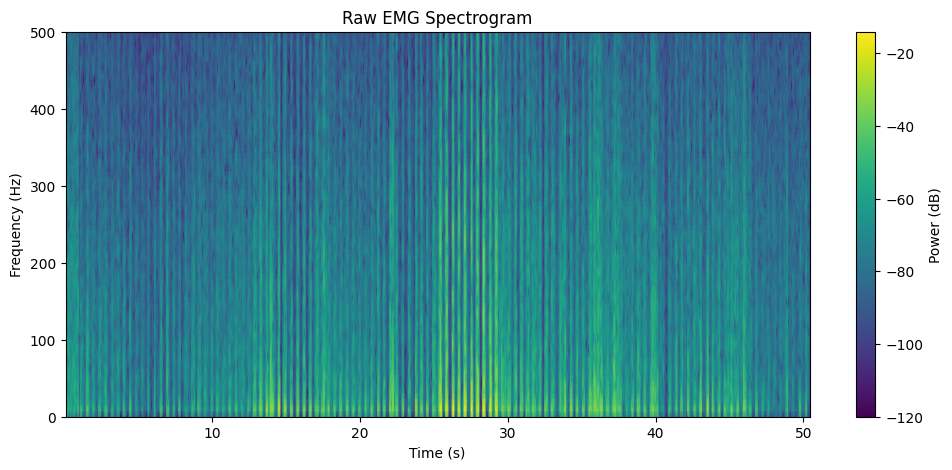

In [32]:
plot_emg_spectrogram(data.iloc[:, 0], title="Raw EMG Spectrogram")